In [ ]:
import numpy as np
import tensorflow as tf
import re
from typing import Dict, List, Text, Tuple,Callable

import matplotlib.pyplot as plt
from matplotlib import colors

from tqdm import tqdm

from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Concatenate, Input, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = "/content/drive/MyDrive/wildfire_dataset/ndws_western_dataset"

tfrecord_files = sorted(
    [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if f.endswith(".tfrecord")]
)

if len(tfrecord_files) == 0:
    raise FileNotFoundError(" No TFRecord files found in the dataset directory!")

print(" Using TFRecord file:", tfrecord_files[0])

raw_dataset = tf.data.TFRecordDataset(tfrecord_files[0])

 Using TFRecord file: /content/drive/MyDrive/wildfire_dataset/ndws_western_dataset/cleaned_eval_ndws_conus_western_000.tfrecord


In [ ]:
for raw_record in raw_dataset.take(1):
    example = tf.train.Example()
    example.ParseFromString(raw_record.numpy())

    # Extract feature names (keys) only
    feature_names = list(example.features.feature.keys())

    print("Feature names in TFRecord:", feature_names)

Feature names in TFRecord: ['gust_med', 'wind_75', 'elevation', 'population', 'chili', 'impervious', 'fuel3', 'viirs_PrevFireMask', 'fuel2', 'viirs_FireMask', 'fuel1', 'pdsi', 'water', 'tmp_day', 'erc', 'NDVI', 'pr', 'wdir_wind', 'wdir_gust', 'bi', 'tmp_75', 'avg_sph', 'wind_avg']


In [ ]:
dataset_path = "/content/drive/MyDrive/wildfire_dataset/ndws_western_dataset"

INPUT_FEATURES = ['elevation', 'wind_75', 'wind_avg', 'tmp_75', 'tmp_day', 'avg_sph',
                  'pr', 'pdsi', 'NDVI', 'population', 'erc', 'viirs_PrevFireMask']
OUTPUT_FEATURES = ['viirs_FireMask']


train_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if "train" in f and f.endswith(".tfrecord")]
test_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if "test" in f and f.endswith(".tfrecord")]
validation_files = [os.path.join(dataset_path, f) for f in os.listdir(dataset_path) if "eval" in f and f.endswith(".tfrecord")]

In [ ]:
# Updated feature titles to match dataset
TITLES_WITH_UNITS = [
    "Precipitation\n(mm, daily total)",  # pr
    "Wind\nspeed at 75m\n(m/s)",         # wind_75
    "Energy\nrelease component\n(index)",# erc
    "Population\ndensity\n(people per km²)",  # population
    "Water\n(% cover)",                   # water
    "Wind\ngust direction\n(degree)",      # wdir_gust
    "Vegetation\nindex (NDVI)",            # NDVI
    "Drought\nindex (PDSI)",               # pdsi
    "Wind\ndirection\n(degree)",           # wdir_wind
    "Topographic\nposition index",         # chili
    "Fuel type 3",                          # fuel3
    "Impervious\nsurface (%)",              # impervious
    "Average\nwind speed (m/s)",            # wind_avg
    "Burning\nindex",                        # bi
    "Previous\nfire mask",                   # viirs_PrevFireMask
    "Fire\nmask",                            # viirs_FireMask
    "Temperature\nat 75m (K)",               # tmp_75
    "Fuel type 2",                           # fuel2
    "Daytime\ntemperature (K)",              # tmp_day
    "Wind\ngust speed (m/s)",                # gust_med
    "Elevation\n(m)",                         # elevation
    "Average\nspecific humidity",             # avg_sph
    "Fuel type 1"                             # fuel1
]

# Updated feature ranges based on dataset features
FEATURE_RANGES = [
    (0.0, 1.0),    # Precipitation (pr)
    (0.5, 6.0),    # Wind speed at 75m (wind_75)
    (0, 100),      # Energy release component (erc)
    (0, 1000),     # Population density (population)
    (0, 100),      # Water cover (water)
    (0, 360),      # Wind gust direction (wdir_gust)
    (0, 1),        # NDVI (Vegetation index)
    (-5, 5),       # Drought index (PDSI)
    (0, 360),      # Wind direction (wdir_wind)
    (-10, 10),     # Topographic position index (chili)
    (0, 3),        # Fuel type 3 (fuel3)
    (0, 100),      # Impervious surface (%) (impervious)
    (0.5, 5.0),    # Average wind speed (wind_avg)
    (0, 200),      # Burning index (bi)
    None,          # Previous fire mask (binary) (viirs_PrevFireMask)
    None,          # Fire mask (binary) (viirs_FireMask)
    (280, 320),    # Temperature at 75m (tmp_75)
    (0, 3),        # Fuel type 2 (fuel2)
    (280, 320),    # Daytime temperature (tmp_day)
    (0.0, 20.0),   # Wind gust speed (gust_med)
    (1750, 2500),  # Elevation (elevation)
    (0.005, 0.015),# Average specific humidity (avg_sph)
    (0, 3)         # Fuel type 1 (fuel1)
]

In [ ]:
def normalize_feature(feature, feature_name):
    """
    Normalization of input features based on predefined feature ranges.

    Args:
        feature (Tensor): The feature tensor to be normalized.
        feature_name (str): Name of the feature, used to determine the normalization method.

    Returns:
        Tensor: The normalized feature.
    """
    if feature_name == 'viirs_PrevFireMask':
        # Previous fire mask is binary; boosting its effect
        return feature * 5.0

    try:
        index = INPUT_FEATURES.index(feature_name)
        feature_range = FEATURE_RANGES[index]

        if feature_range is not None:
            feature_min, feature_max = feature_range
            # Min-max normalize and clip to [0, 1]
            norm = (feature - feature_min) / (feature_max - feature_min + 1e-6)
            return tf.clip_by_value(norm, 0.0, 1.0)
        else:
            # Fallback to z-score normalization if range is not defined
            return (feature - tf.reduce_mean(feature)) / (tf.math.reduce_std(feature) + 1e-6)

    except ValueError:
        raise ValueError(f"Feature '{feature_name}' not found in INPUT_FEATURES.")

def _parse_function(example_proto):
    """
    Parsing and preprocessing of a serialized TFRecord example.

    Args:
        example_proto (Tensor): A serialized TFRecord example.

    Returns:
        Tuple[Tensor, Tensor]:
            - inputs: A tensor containing concatenated and normalized input features
                      with shape [64, 64, num_features].
            - label: A tensor containing the processed FireMask label with shape [64, 64, 1].
    """

    # Feature description dictionary: specifies the shape and types of features
    feature_description = {}
    for feature_name in INPUT_FEATURES + OUTPUT_FEATURES:
        feature_description[feature_name] = tf.io.FixedLenFeature([64, 64], tf.float32)

    # Parse the input tf.train.Example proto using the dictionary above
    parsed_example = tf.io.parse_single_example(example_proto, feature_description)

    # Create a single tensor from the input features
    inputs_list = []
    for feature_name in INPUT_FEATURES:
        feature = tf.expand_dims(parsed_example[feature_name], axis=-1)  # Shape: [64, 64, 1]
        normalized_feature = normalize_feature(feature, feature_name)
        inputs_list.append(normalized_feature)
    inputs = tf.concat(inputs_list, axis=-1)  # Shape of inputs: [64, 64, 12]

    # The label (FireMask), is expanded to have a shape [64, 64, 1]
    label = tf.clip_by_value(parsed_example['viirs_FireMask'], 0.0, 1.0)  # Simplified binarization
    return inputs, label

In [ ]:
def get_dataset(file_pattern: Text, batch_size: int) -> tf.data.Dataset:

    """
    Creation and preprocessing of a dataset for training or evaluation.

    Args:
        file_pattern (Text): File path pattern to match TFRecord files.
        batch_size (int): Number of samples per batch.

    Returns:
        tf.data.Dataset: A preprocessed dataset with shuffled, batched, and prefetched data.
    """

    dataset = tf.data.Dataset.list_files(file_pattern) #Creates a dataset of filepaths matching file_pattern, which each filepath representing a TFRecord file
    dataset = dataset.interleave(
        lambda x: tf.data.TFRecordDataset(x), # Opens file and creates a TFRecordDataset, which reads the serialized examples from the file.
        num_parallel_calls=tf.data.AUTOTUNE   # enable automatic parallel processing
    )
    dataset = dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE) # parse the serialized data in each TFRecord to split inputs and labels (see previous cell)
    dataset = dataset.shuffle(buffer_size=1000) # Randomly shuffles the data by using a buffer of size 1000 (random samples are taken from buffer)
    dataset = dataset.batch(batch_size) # Batch = subset of data the we expose the model to during training
    dataset = dataset.prefetch(buffer_size = tf.data.experimental.AUTOTUNE) # speeds up training by overlapping preprocessing and model execution
    return dataset

In [ ]:
BATCH_SIZE = 8

train_dataset = (get_dataset(train_files, batch_size=BATCH_SIZE)
                 .shuffle(1000)   # Shuffle before repeating
                 .cache()         # Cache before repeating to avoid redundant computations
                 .repeat()        # Repeat after caching to avoid duplicating shuffling
                 .prefetch(tf.data.AUTOTUNE))  # Prefetch to speed up data loading

validation_dataset = (get_dataset(validation_files, batch_size=BATCH_SIZE)
                      .cache()
                      .repeat()
                      .prefetch(tf.data.AUTOTUNE))

test_dataset = (get_dataset(test_files, batch_size=BATCH_SIZE)
                .cache()
                .prefetch(tf.data.AUTOTUNE))

In [ ]:
import os
import glob
import tensorflow as tf

dataset_path = "/content/drive/MyDrive/wildfire_dataset/ndws_western_dataset"

# Get list of all TFRecord files
train_files = glob.glob(os.path.join(dataset_path, "*.tfrecord"))

# Count total number of samples across all files
num_samples = 0
for file in train_files:
    num_samples += sum(1 for _ in tf.data.TFRecordDataset(file))

# Calculate STEPS_PER_EPOCH based on total samples
STEPS_PER_EPOCH = num_samples // BATCH_SIZE

print(f"Total Samples: {num_samples}")
print(f"Steps Per Epoch: {STEPS_PER_EPOCH}")

Total Samples: 20097
Steps Per Epoch: 2512


In [ ]:
import gc
import tensorflow as tf
from tensorflow.keras.metrics import MeanIoU, Recall, Precision
from tensorflow.keras.backend import clear_session, epsilon

def evaluate_model(model, eval_dataset: tf.data.Dataset):
    """
    Evaluates a trained model using MeanIoU, Recall, Precision, and F1 Score while preventing memory leaks.

    Args:
        model: Trained U-Net model.
        eval_dataset (tf.data.Dataset): Dataset containing evaluation inputs and ground-truth labels.

    Returns:
        tuple: (Mean IoU, Recall, Precision, F1 Score)
    """
    # Metrics Initialization
    iou_metric = MeanIoU(num_classes=2)
    recall_metric = Recall()
    precision_metric = Precision()

    # Iterate through dataset
    for batch in eval_dataset.as_numpy_iterator():
        inputs, labels = batch

        # Get model predictions
        predictions = model.predict(inputs, verbose=0)

        # Update metrics (thresholded to binary masks)
        predictions_binary = (predictions > 0.5).astype('float32')

        iou_metric.update_state(labels, predictions_binary)
        recall_metric.update_state(labels, predictions_binary)
        precision_metric.update_state(labels, predictions_binary)

        # Free memory
        del inputs, labels, predictions, predictions_binary
        gc.collect()

    # Compute final metric results
    mean_iou = iou_metric.result().numpy()
    recall = recall_metric.result().numpy()
    precision = precision_metric.result().numpy()

    # F1 Score computation (with epsilon to avoid divide by zero)
    f1_score = 2 * (precision * recall) / (precision + recall + epsilon())

    # Clear TF session to free memory
    clear_session()

    return mean_iou, recall, precision, f1_score


In [ ]:
class IoUScore(tf.keras.metrics.Metric):
    def __init__(self, name="IoU_score", threshold=0.5, **kwargs):
        super(IoUScore, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.total_iou = self.add_weight(name="total_iou", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > self.threshold, dtype=tf.float32)

        y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
        y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

        intersection = tf.reduce_sum(y_true * y_pred, axis=1)
        union = tf.reduce_sum(y_true + y_pred, axis=1) - intersection
        iou = intersection / (union + tf.keras.backend.epsilon())
        mean_iou = tf.reduce_mean(iou)

        self.total_iou.assign_add(mean_iou)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_iou / tf.maximum(self.count, 1.0)

    def reset_states(self):
        self.total_iou.assign(0.0)
        self.count.assign(0.0)


class DiceCoefficient(tf.keras.metrics.Metric):
    def __init__(self, name="dice_coefficient", threshold=0.5, **kwargs):
        super(DiceCoefficient, self).__init__(name=name, **kwargs)
        self.threshold = threshold
        self.total_dice = self.add_weight(name="total_dice", initializer="zeros")
        self.count = self.add_weight(name="count", initializer="zeros")

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(y_pred > self.threshold, dtype=tf.float32)

        y_true = tf.reshape(y_true, [tf.shape(y_true)[0], -1])
        y_pred = tf.reshape(y_pred, [tf.shape(y_pred)[0], -1])

        intersection = tf.reduce_sum(y_true * y_pred, axis=1)
        dice = (2. * intersection) / (
            tf.reduce_sum(y_true, axis=1) + tf.reduce_sum(y_pred, axis=1) + tf.keras.backend.epsilon())
        mean_dice = tf.reduce_mean(dice)

        self.total_dice.assign_add(mean_dice)
        self.count.assign_add(1.0)

    def result(self):
        return self.total_dice / tf.maximum(self.count, 1.0)

    def reset_states(self):
        self.total_dice.assign(0.0)
        self.count.assign(0.0)

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Conv2DTranspose, Concatenate, \
    BatchNormalization, Activation, Dropout, Add, Multiply, Layer
from tensorflow.keras.models import Model
from tensorflow.keras.regularizers import l2


# ✅ 1. Static-safe resize layer
class ResizeToMatchFixed(Layer):
    def call(self, inputs):
        skip, target = inputs
        # Use target.shape instead of tf.shape() to keep it static
        height, width = target.shape[1], target.shape[2]
        return tf.image.resize(skip, size=(height, width), method='bilinear')


resize = ResizeToMatchFixed()
def conv_bn_relu(x, filters, kernel_size=3, dropout_rate=0.0, l2_reg=1e-4):
    x = Conv2D(filters, kernel_size, padding='same', kernel_regularizer=l2(l2_reg))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    if dropout_rate > 0.0:
        x = Dropout(dropout_rate)(x)
    return x

def attention_gate(x, g, inter_channels):
    g_resized = resize([g, x])
    theta_x = Conv2D(inter_channels, (1, 1), padding='same')(x)
    phi_g = Conv2D(inter_channels, (1, 1), padding='same')(g_resized)
    add = Add()([theta_x, phi_g])
    relu = Activation('relu')(add)
    psi = Conv2D(1, (1, 1), padding='same')(relu)
    sigmoid = Activation('sigmoid')(psi)
    return Multiply()([x, sigmoid])
def rsu_block(x, mid_channels, out_channels, depth, dropout_rate=0.0, l2_reg=1e-4):
    skips = []
    x_in = conv_bn_relu(x, out_channels, 3, dropout_rate, l2_reg)
    x = x_in

    for i in range(depth - 1):
        x = conv_bn_relu(x, mid_channels, 3, dropout_rate, l2_reg)
        skips.append(x)
        x = MaxPooling2D(pool_size=(2, 2))(x)

    x = conv_bn_relu(x, mid_channels, 3, dropout_rate, l2_reg)

    for i in reversed(range(depth - 1)):
        x = Conv2DTranspose(mid_channels, (2, 2), strides=(2, 2), padding='same')(x)
        skip_resized = resize([skips[i], x])
        x = Concatenate()([x, skip_resized])
        x = conv_bn_relu(x, mid_channels, 3, dropout_rate, l2_reg)

    x_out = conv_bn_relu(x, out_channels, 3, dropout_rate, l2_reg)
    x_in_resized = resize([x_in, x_out])
    return Add()([x_out, x_in_resized])
def build_attention_u2net(input_shape=(64, 64, 12), dropout_rate=0.2, l2_reg=1e-4):
    inputs = Input(shape=input_shape)

    # Encoder
    e1 = rsu_block(inputs, 32, 64, depth=2, dropout_rate=dropout_rate, l2_reg=l2_reg)
    p1 = MaxPooling2D((2, 2))(e1)

    e2 = rsu_block(p1, 64, 128, depth=3, dropout_rate=dropout_rate, l2_reg=l2_reg)
    p2 = MaxPooling2D((2, 2))(e2)

    e3 = rsu_block(p2, 128, 256, depth=4, dropout_rate=dropout_rate, l2_reg=l2_reg)
    p3 = MaxPooling2D((2, 2))(e3)

    e4 = rsu_block(p3, 256, 512, depth=4, dropout_rate=dropout_rate, l2_reg=l2_reg)
    p4 = MaxPooling2D((2, 2))(e4)

    b = rsu_block(p4, 256, 512, depth=2, dropout_rate=dropout_rate, l2_reg=l2_reg)

    # Decoder
    d4 = Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(b)
    attn4 = attention_gate(e4, d4, 256)
    d4 = Concatenate()([d4, resize([attn4, d4])])
    d4 = rsu_block(d4, 256, 512, depth=4, dropout_rate=dropout_rate, l2_reg=l2_reg)

    d3 = Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(d4)
    attn3 = attention_gate(e3, d3, 128)
    d3 = Concatenate()([d3, resize([attn3, d3])])
    d3 = rsu_block(d3, 128, 256, depth=4, dropout_rate=dropout_rate, l2_reg=l2_reg)

    d2 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(d3)
    attn2 = attention_gate(e2, d2, 64)
    d2 = Concatenate()([d2, resize([attn2, d2])])
    d2 = rsu_block(d2, 64, 128, depth=3, dropout_rate=dropout_rate, l2_reg=l2_reg)

    d1 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(d2)
    attn1 = attention_gate(e1, d1, 32)
    d1 = Concatenate()([d1, resize([attn1, d1])])
    d1 = rsu_block(d1, 32, 64, depth=2, dropout_rate=dropout_rate, l2_reg=l2_reg)

    outputs = Conv2D(1, (1, 1), activation='sigmoid')(d1)
    return Model(inputs, outputs, name="Attention_U2Net")


In [ ]:
# Optimized Dice Loss
from tensorflow.keras.losses import BinaryCrossentropy

# Combined Loss Function (Dice Loss + BCE)
def combined_loss(y_true, y_pred):
    bce = BinaryCrossentropy()(y_true, y_pred)  # Correct way to use the BinaryCrossentropy loss
    dice = dice_loss(y_true, y_pred)
    return tf.reduce_mean(0.5 * bce + 0.5 * dice)  # Mean ensures batch-wise stability

def dice_loss(y_true, y_pred, smooth=1e-6):
    y_pred = tf.clip_by_value(y_pred, smooth, 1 - smooth)  # Prevent instability
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1 - (2. * intersection + smooth) / (union + smooth)

In [ ]:
att_u2net_model = build_attention_u2net()
att_u2net_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001, clipnorm=1.0),
    loss=combined_loss,  # ← using your Dice + BCE hybrid
    metrics=[
        IoUScore(),             # Custom IoU
        DiceCoefficient(),      # Custom Dice
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()
    ]
)
att_u2net_model.summary()

Model: "Attention_U2Net"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 64,    │          0 │ -                 │
│ (InputLayer)        │ 12)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 64,    │      6,976 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 64,    │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64, 64,    │          0 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 64,    │     18,464 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ activation_1[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 32,    │          0 │ dropout_1[0][0]   │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 32, 32,    │      9,248 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 64, 64,    │      4,128 │ dropout_2[0][0]   │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resize_to_match_fi… │ (None, 64, 64,    │          0 │ dropout_1[0][0],  │
│ (ResizeToMatchFixe… │ 64)               │            │ conv2d_transpose… │
│                     │                   │            │ dropout[0][0],    │
│                     │                   │            │ dropout_4[0][0],

 Total params: 38,797,093 (148.00 MB)

 Trainable params: 38,773,413 (147.91 MB)

 Non-trainable params: 23,680 (92.50 KB)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.losses import BinaryCrossentropy


EPOCHS = 10

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(
    monitor='val_dice_coefficient',  # Monitor dice coefficient instead of val_loss
    patience=4,                     # Adjusted patience to stop at epoch 4
    restore_best_weights=True,       # Restore best weights after stopping
    verbose=1,
    mode="max"
)

# Reduce LR when validation loss stops improving (trigger earlier)
reduce_lr = ReduceLROnPlateau(
    monitor='val_dice_coefficient',  # Monitor dice coefficient instead of val_loss
    factor=0.7,                      # Smaller factor to reduce learning rate less aggressively
    patience=2,                      # Trigger LR reduction earlier (at epoch 3)
    min_lr=1e-6,                     # Keep a small minimum learning rate
    verbose=1,
    mode="max"
)

# Save the best model
checkpoint = ModelCheckpoint(
    "best_att_u2net_model.keras", monitor="val_dice_coefficient",  # Monitor dice coefficient instead of val_loss
    save_best_only=True, verbose=1,
    mode='max'
)

# Train the model
history = att_u2net_model.fit(
    train_dataset,
    epochs=EPOCHS,
    steps_per_epoch=STEPS_PER_EPOCH,
    validation_data=validation_dataset,
    validation_steps=STEPS_PER_EPOCH // 4,  # Avoid excessive validation overhead
    callbacks=[early_stopping, reduce_lr, checkpoint]
)

Epoch 1/10
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - IoU_score: 0.2836 - dice_coefficient: 0.4134 - loss: 0.3704 - precision: 0.4354 - recall: 0.5141
Epoch 1: val_dice_coefficient improved from None to 0.41426, saving model to best_att_u2net_model.keras

Epoch 1: finished saving model to best_att_u2net_model.keras
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 426s 169ms/step - IoU_score: 0.2844 - dice_coefficient: 0.4142 - loss: 0.3724 - precision: 0.4370 - recall: 0.5130 - val_IoU_score: 0.2846 - val_dice_coefficient: 0.4143 - val_loss: 0.4378 - val_precision: 0.4965 - val_recall: 0.4547 - learning_rate: 0.0010
Epoch 2/10
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 0s 158ms/step - IoU_score: 0.2852 - dice_coefficient: 0.4146 - loss: 0.3707 - precision: 0.4436 - recall: 0.5211
Epoch 2: val_dice_coefficient did not improve from 0.41426
2512/2512 ━━━━━━━━━━━━━━━━━━━━ 418s 166ms/step - IoU_score: 0.2859 - dice_coefficient: 0.4158 - loss: 0.3692 - precision: 0.4439 - recall: 0.5192 - val_IoU_score: 1.1709e-05 - 

In [ ]:
print("Evaluating on test data...")

IoU, Recall, Precision, F1 = evaluate_model(att_u2net_model, test_dataset)

print(f"IoU Score: {IoU:.4f}")
print(f"Recall: {Recall:.4f}")
print(f"Precision: {Precision:.4f}")
print(f"F1 Score: {F1:.4f}")

Evaluating on test data...
IoU Score: 0.6164
Recall: 0.4377
Precision: 0.4159
F1 Score: 0.4265


In [ ]:
def show_inference(n_rows: int, features: tf.Tensor, label: tf.Tensor, prediction_function: Callable[[tf.Tensor], tf.Tensor]) -> None:
    """
    Show model inference through images.
    """
    from matplotlib import pyplot as plt
    from matplotlib import colors

    CMAP = colors.ListedColormap(['black', 'silver', 'orangered'])
    BOUNDS = [-1, -0.1, 0.001, 1]
    NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

    fig = plt.figure(figsize=(15, n_rows * 4))
    prediction = prediction_function(features)

    for i in range(n_rows):
        plt.subplot(n_rows, 3, i * 3 + 1)
        plt.title("Previous day fire")
        plt.imshow(features[i, :, :, -1], cmap=CMAP, norm=NORM)
        plt.axis('off')

        plt.subplot(n_rows, 3, i * 3 + 2)
        plt.title("True next day fire")
        plt.imshow(label[i], cmap=CMAP, norm=NORM)
        plt.axis('off')

        plt.subplot(n_rows, 3, i * 3 + 3)
        plt.title("Predicted next day fire")
        plt.imshow(prediction[i], cmap=CMAP, norm=NORM)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step


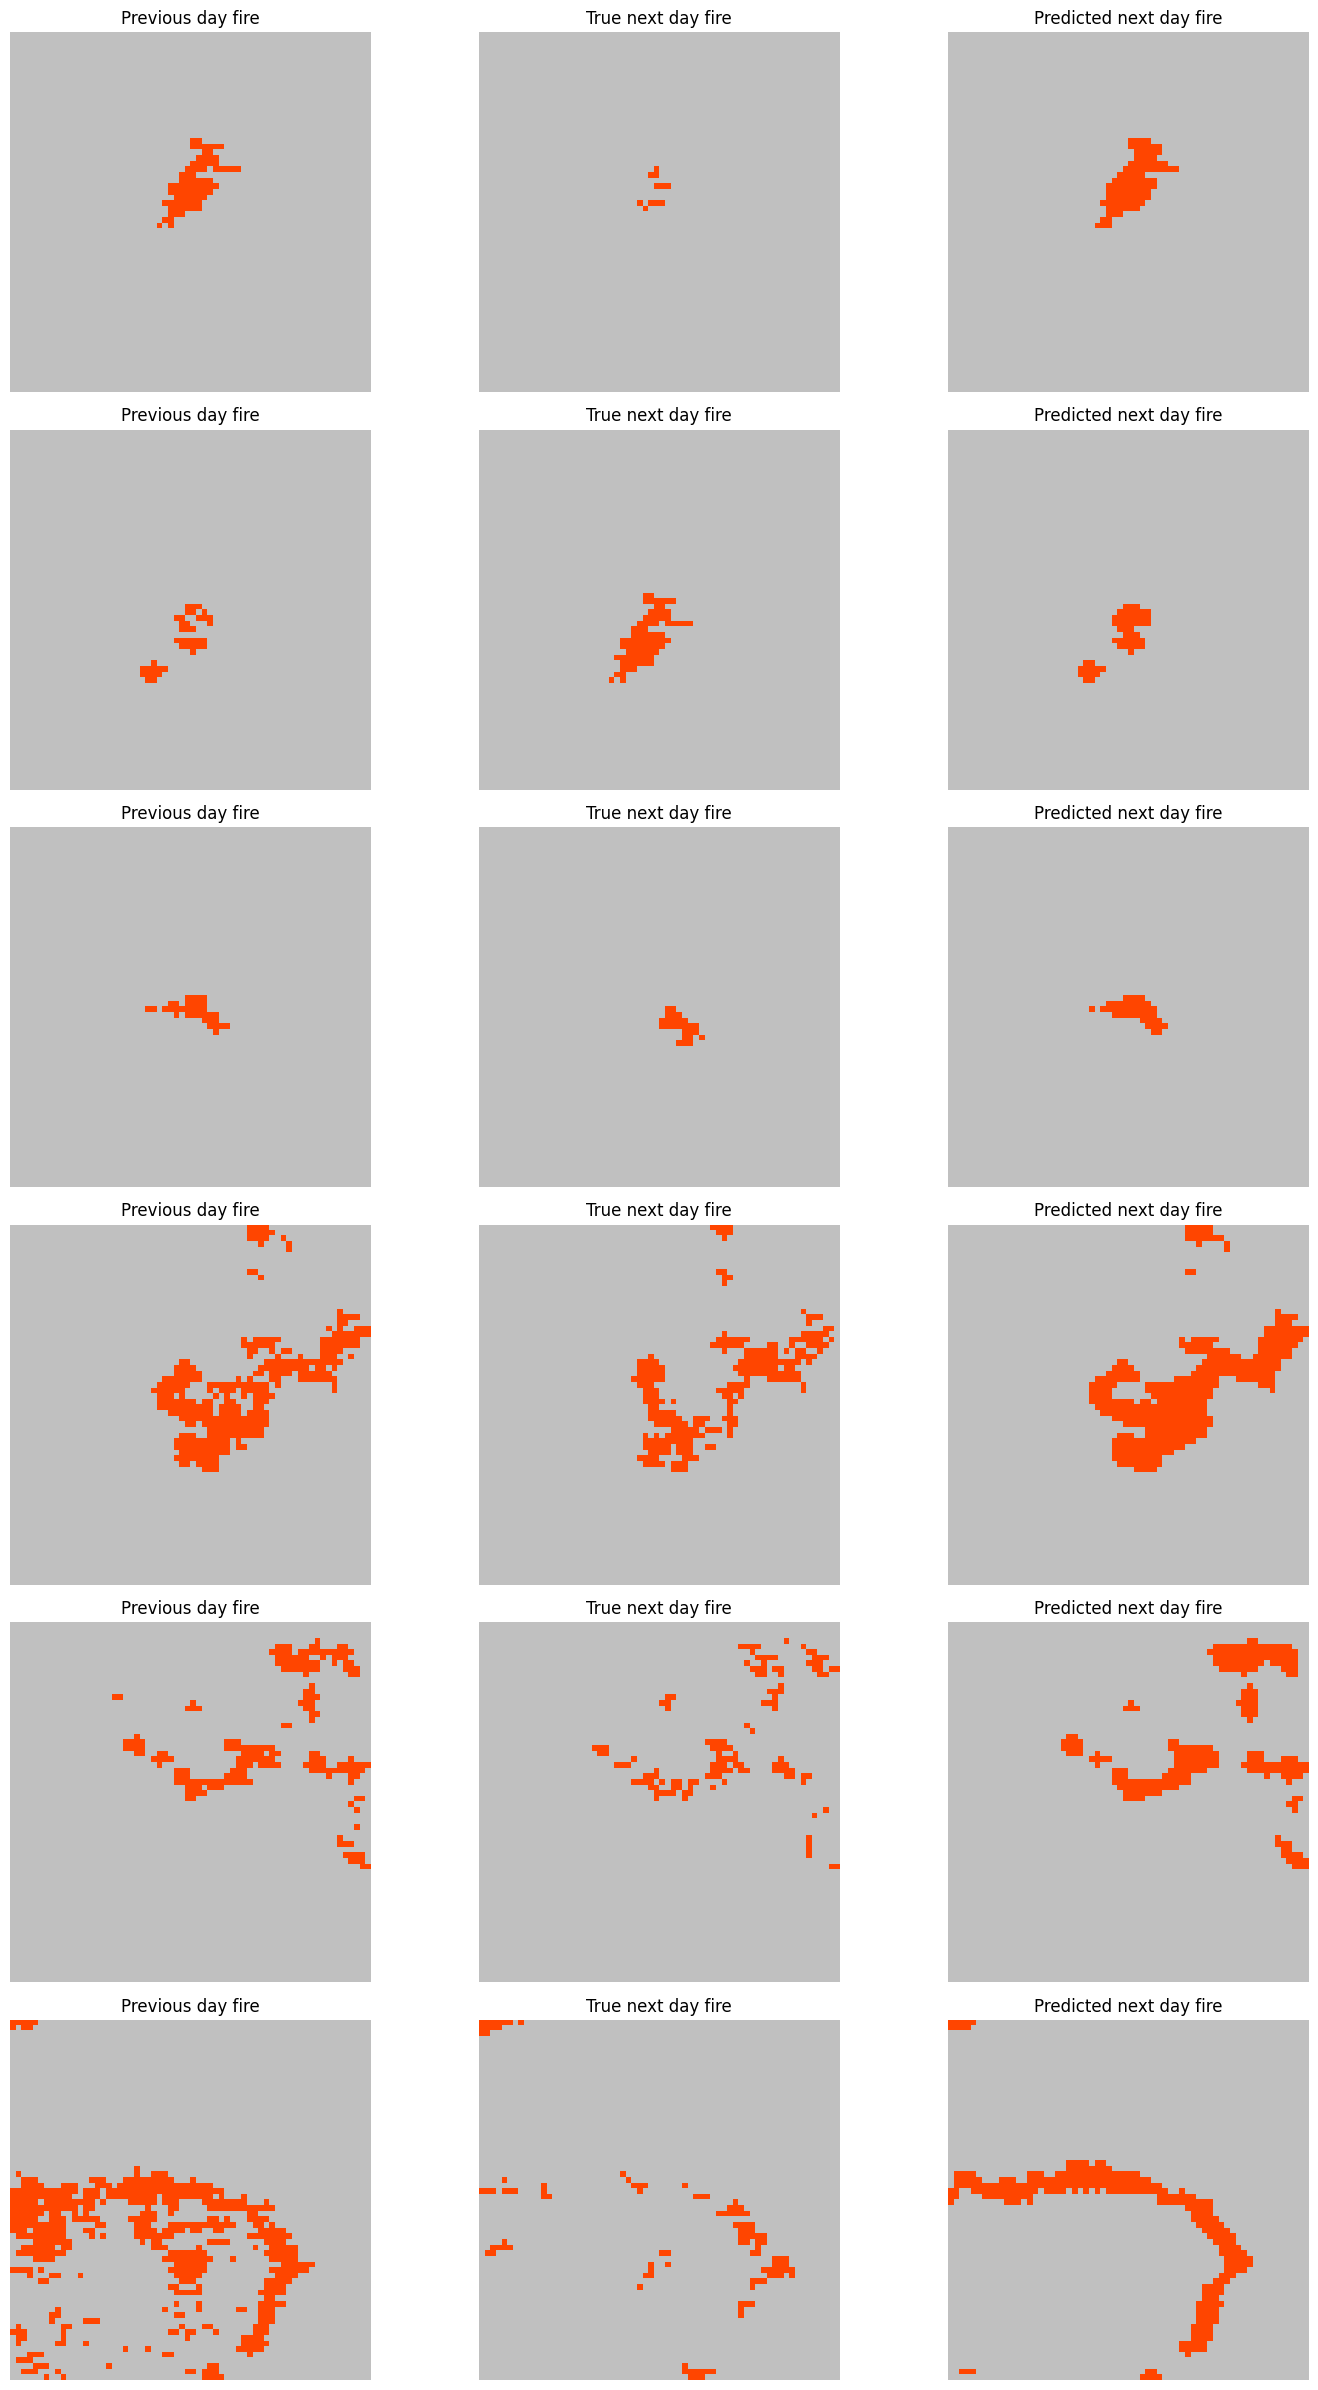

In [ ]:
features, labels = next(iter(test_dataset))
show_inference(6, features, labels, lambda x: tf.where(att_u2net_model.predict(x) > 0.5, 1, 0)[:,:,:,0])

In [ ]:
def get_dataset_for_predictions(file_pattern: Text, batch_size: int, shuffle: bool = True, repeat: bool = True) -> tf.data.Dataset:
    """
    Loads and preprocesses TFRecord files into a dataset.

    Args:
        file_pattern (Text): Pattern or list of TFRecord files.
        batch_size (int): Batch size for training or inference.
        shuffle (bool): Whether to shuffle the dataset.
        repeat (bool): Whether to repeat the dataset (for training).

    Returns:
        tf.data.Dataset
    """
    dataset = tf.data.Dataset.list_files(file_pattern, shuffle=shuffle)

    dataset = dataset.interleave(
        lambda x: tf.data.TFRecordDataset(x),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    dataset = dataset.map(_parse_function, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)
    if repeat:
        dataset = dataset.repeat()

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)

    return dataset

In [ ]:
val_dataset_for_stacking = get_dataset_for_predictions(validation_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)
test_dataset_for_stacking = get_dataset_for_predictions(test_files, batch_size=BATCH_SIZE, shuffle=False, repeat=False)


In [ ]:
import os
import numpy as np
from tqdm import tqdm

def save_predictions_and_ground_truths(model, dataset, pred_dir, gt_dir, model_name="model", mode="val"):
    """
    Saves both predicted binary masks and ground truth masks from a dataset.

    Args:
        model (tf.keras.Model): Trained segmentation model.
        dataset (tf.data.Dataset): Dataset yielding (inputs, labels).
        pred_dir (str): Directory to save predicted masks.
        gt_dir (str): Directory to save ground truth masks.
        model_name (str): For logging.
        mode (str): 'val' or 'test' or custom tag.
    """
    os.makedirs(pred_dir, exist_ok=True)
    os.makedirs(gt_dir, exist_ok=True)
    idx = 0

    print(f"[{model_name.upper()} - {mode.upper()}] Saving predicted and GT masks...")

    for batch_idx, (inputs, labels) in enumerate(tqdm(dataset)):
        predictions = model.predict(inputs, verbose=0)
        binary_preds = (predictions > 0.5).astype(np.uint8)

        for i in range(binary_preds.shape[0]):
            pred_mask = binary_preds[i].squeeze()
            gt_mask = labels[i].numpy().squeeze()

            np.save(os.path.join(pred_dir, f"mask_{idx}.npy"), pred_mask)
            np.save(os.path.join(gt_dir, f"mask_{idx}.npy"), gt_mask.astype(np.uint8))
            idx += 1

    print(f"[{model_name.upper()} - {mode.upper()}] Saved {idx} predicted and ground truth masks.")


In [ ]:
save_predictions_and_ground_truths(
    model=att_u2net_model,
    dataset=val_dataset_for_stacking,
    pred_dir="predicted_masks_att_u2net_val",
    gt_dir="ground_truth_masks_att_u2net_val",
    model_name="att_u2net",
    mode="val"
)


[ATT_U2NET - VAL] Saving predicted and GT masks...


538it [01:35,  5.64it/s]

[ATT_U2NET - VAL] Saved 4301 predicted and ground truth masks.


In [ ]:
save_predictions_and_ground_truths(
    model=att_u2net_model,
    dataset=test_dataset_for_stacking,
    pred_dir="predicted_masks_att_u2net_test",
    gt_dir="ground_truth_masks_att_u2net_test",
    model_name="att_u2net",
    mode="test"
)


[ATT_U2NET - TEST] Saving predicted and GT masks...


775it [02:07,  6.06it/s]

[ATT_U2NET - TEST] Saved 6196 predicted and ground truth masks.


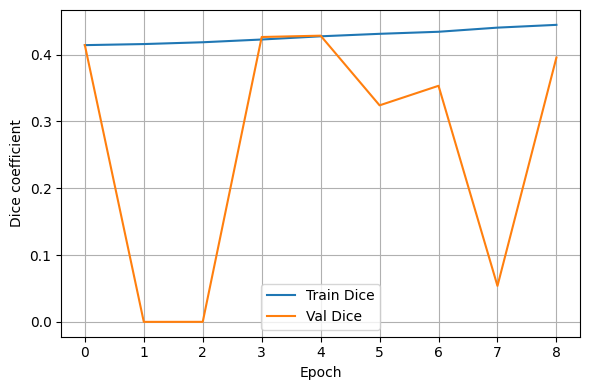

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice coefficient")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("attn_u2net_dice_curves.png", dpi=300)

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import colors
import numpy as np

def plot_predictions_grid(dataset, model, n_rows=6):
    CMAP = colors.ListedColormap(["black", "silver", "orangered"])
    BOUNDS = [-1, -0.1, 0.001, 1]
    NORM = colors.BoundaryNorm(BOUNDS, CMAP.N)

    inputs, labels = next(dataset.as_numpy_iterator())
    preds = model.predict(inputs, verbose=0)
    preds_bin = (preds > 0.5).astype("float32")

    fig, axes = plt.subplots(n_rows, 3, figsize=(9, 3*n_rows))
    for i in range(n_rows):
        # Previous fire mask
        prev_idx = INPUT_FEATURES.index("viirsPrevFireMask")
        axes[i,0].imshow(inputs[i,:,:,prev_idx], cmap=CMAP, norm=NORM)
        axes[i,0].set_title("Previous Fire")
        axes[i,0].axis("off")

        # Ground truth
        axes[i,1].imshow(labels[i,:,:,0], cmap=CMAP, norm=NORM)
        axes[i,1].set_title("Ground Truth")
        axes[i,1].axis("off")

        # Prediction
        axes[i,2].imshow(preds_bin[i,:,:,0], cmap=CMAP, norm=NORM)
        axes[i,2].set_title("Prediction")
        axes[i,2].axis("off")

    plt.tight_layout()
    plt.savefig("attn_u2net_6x3_grid.png", dpi=300)

In [ ]:
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy

def diceloss(y_true, y_pred, smooth=1e-6):
    y_pred = tf.clip_by_value(y_pred, smooth, 1.0 - smooth)
    intersection = tf.reduce_sum(y_true * y_pred)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred)
    return 1.0 - (2.0 * intersection + smooth) / (union + smooth)

def combinedloss(y_true, y_pred):
    bce = binary_crossentropy(y_true, y_pred)
    dice = diceloss(y_true, y_pred)
    return tf.reduce_mean(0.5 * bce + 0.5 * dice)

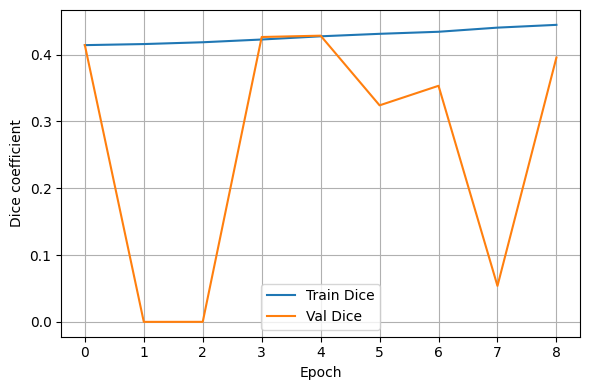

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice coefficient")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("attn_u2net_dice_curves.png", dpi=300)
plt.show()

In [ ]:
import tensorflow as tf
for k, v in globals().items():
    if isinstance(v, tf.keras.Model):
        print(k)

att_u2net_model


In [ ]:
print(INPUT_FEATURES)

['elevation', 'wind_75', 'wind_avg', 'tmp_75', 'tmp_day', 'avg_sph', 'pr', 'pdsi', 'NDVI', 'population', 'erc', 'viirs_PrevFireMask']


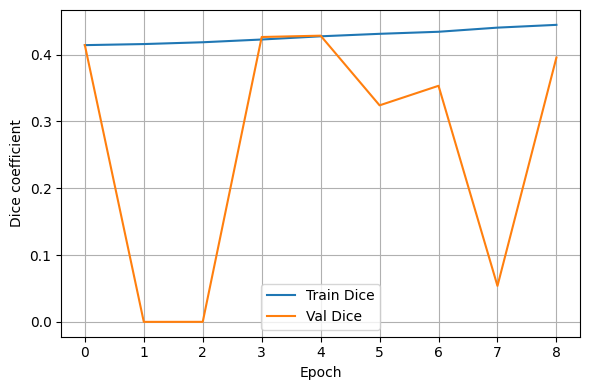

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history.history["dice_coefficient"], label="Train Dice")
plt.plot(history.history["val_dice_coefficient"], label="Val Dice")
plt.xlabel("Epoch")
plt.ylabel("Dice coefficient")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("attn_u2net_dice_curves.png", dpi=300)
plt.show()

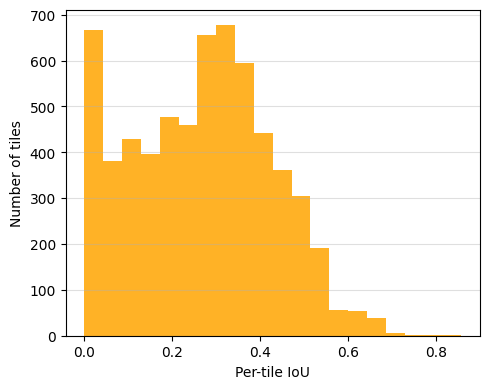

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def per_tile_iou(model, dataset):
    ious = []
    for inputs, labels in dataset.as_numpy_iterator():
        # ensure labels have shape (B,64,64,1)
        if labels.ndim == 3:
            labels = np.expand_dims(labels, axis=-1)

        preds = model.predict(inputs, verbose=0)
        preds_bin = (preds > 0.5).astype("float32")

        inter = np.sum(labels * preds_bin, axis=(1,2,3))
        union = np.sum(labels + preds_bin, axis=(1,2,3)) - inter
        ious_batch = inter / (union + 1e-6)
        ious.extend(ious_batch.tolist())
    return np.array(ious)

attn_ious = per_tile_iou(att_u2net_model, test_dataset)

plt.figure(figsize=(5,4))
plt.hist(attn_ious, bins=20, color="orange", alpha=0.85)
plt.xlabel("Per-tile IoU")
plt.ylabel("Number of tiles")
plt.grid(True, axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig("attn_u2net_iou_hist.png", dpi=300)
plt.show()

In [ ]:

# Zip predicted and ground truth masks
!zip -r predicted_unet_val.zip predicted_masks_att_u2net_val
!zip -r predicted_attunet_test.zip predicted_masks_att_u2net_test
!zip -r ground_truth_val.zip ground_truth_masks_att_u2net_val
!zip -r ground_truth_test.zip ground_truth_masks_att_u2net_test

  adding: predicted_masks_att_u2net_val/ (stored 0%)
  adding: predicted_masks_att_u2net_val/mask_392.npy (deflated 97%)
  adding: predicted_masks_att_u2net_val/mask_3460.npy (deflated 97%)
  adding: predicted_masks_att_u2net_val/mask_442.npy (deflated 97%)
  adding: predicted_masks_att_u2net_val/mask_3078.npy (deflated 97%)
  adding: predicted_masks_att_u2net_val/mask_2618.npy (deflated 97%)
  adding: predicted_masks_att_u2net_val/mask_1484.npy (deflated 94%)
  adding: predicted_masks_att_u2net_val/mask_2574.npy (deflated 96%)
  adding: predicted_masks_att_u2net_val/mask_972.npy (deflated 96%)
  adding: predicted_masks_att_u2net_val/mask_3035.npy (deflated 94%)
  adding: predicted_masks_att_u2net_val/mask_1861.npy (deflated 95%)
  adding: predicted_masks_att_u2net_val/mask_2410.npy (deflated 96%)
  adding: predicted_masks_att_u2net_val/mask_1847.npy (deflated 96%)
  adding: predicted_masks_att_u2net_val/mask_2658.npy (deflated 95%)
  adding: predicted_masks_att_u2net_val/mask_1636.npy

In [ ]:
# ════════════════════════════════════════════════════════════════════════════
#  Research-Grade Metrics & Visualisation — Attention U2-Net
#  Run this cell after training, OR run as-is (history hardcoded from saved run).
# ════════════════════════════════════════════════════════════════════════════

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import MaxNLocator
import warnings
warnings.filterwarnings('ignore')

# ── Recorded training history ─────────────────────────────────────────────────
# Replace with:  history_data = history.history   if running live
history_data = {
    'loss':                [0.3724, 0.3692, 0.3639, 0.3451, 0.3397, 0.3343, 0.3329, 0.3186, 0.3132],
    'IoU_score':           [0.2844, 0.2859, 0.2881, 0.2918, 0.2959, 0.2991, 0.3017, 0.3076, 0.3114],
    'dice_coefficient':    [0.4142, 0.4158, 0.4185, 0.4226, 0.4274, 0.4312, 0.4342, 0.4404, 0.4446],
    'recall':              [0.513, 0.5192, 0.523, 0.5321, 0.5401, 0.5479, 0.5535, 0.5658, 0.5712],
    'precision':           [0.437, 0.4439, 0.4504, 0.4625, 0.4728, 0.4815, 0.4879, 0.5044, 0.5121],
    'val_loss':            [0.4378, 0.7781, 0.7613, 0.3419, 0.3386, 0.39, 0.3763, 7.4866, 0.3527],
    'val_IoU_score':       [0.2846, 0.0, 0.0, 0.2942, 0.2951, 0.2171, 0.2383, 0.0286, 0.2715],
    'val_dice_coefficient':[0.4143, 0.0, 0.0, 0.4264, 0.4284, 0.3241, 0.3534, 0.0539, 0.3957],
    'val_recall':          [0.4547, 0.0, 0.0, 0.5178, 0.5129, 0.3432, 0.3497, 0.9818, 0.4306],
    'val_precision':       [0.4965, 0.125, 0.4815, 0.456, 0.4717, 0.4858, 0.5252, 0.0287, 0.5211],
    'learning_rate':       [0.001, 0.001, 0.001, 0.0007, 0.0007, 0.0007, 0.0007, 0.00049, 0.00049],
}

epochs     = list(range(1, len(history_data['loss']) + 1))
best_epoch = 5

# ── Test results ──────────────────────────────────────────────────────────────
test_iou        = 0.6164
test_recall     = 0.4377
test_precision  = 0.4159
test_f1         = 0.4265
test_dice       = test_f1

# ── Baseline U-Net results (for comparison plots) ─────────────────────────────
baseline_iou        = 0.484
baseline_recall     = 0.2769
baseline_precision  = 0.4339
baseline_f1         = 0.3381
baseline_dice       = baseline_f1

# ── Style ─────────────────────────────────────────────────────────────────────
C_TRAIN = '#E05A2B'
C_VAL   = '#2B6CB0'
C_BEST  = '#2D9E5C'
C_GRID  = '#E8E8E8'
plt.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.color'       : C_GRID,
    'grid.linewidth'   : 0.6,
    'figure.dpi'       : 150,
})

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 1 — Training curves  (2 × 2)
# ════════════════════════════════════════════════════════════════════════════
fig1, axes = plt.subplots(2, 2, figsize=(13, 9))
fig1.suptitle('Attention U2-Net — Training & Validation Curves',
              fontsize=15, fontweight='bold', y=1.01)

subplots = [
    ('loss',             'val_loss',             'Loss (Dice-BCE)',   True),
    ('IoU_score',        'val_IoU_score',        'IoU Score',         False),
    ('dice_coefficient', 'val_dice_coefficient', 'Dice Coefficient',  False),
    ('recall',           'val_recall',           'Recall',            False),
]

for ax, (tr_key, val_key, title, _) in zip(axes.flat[:3], subplots[:3]):
    tr  = history_data[tr_key]
    val = history_data[val_key]
    ax.plot(epochs, tr,  color=C_TRAIN, lw=2, marker='o', ms=4, label='Train')
    ax.plot(epochs, val, color=C_VAL,   lw=2, marker='s', ms=4, linestyle='--', label='Validation')
    ax.axvline(best_epoch, color=C_BEST, lw=1.2, linestyle=':', label=f'Best epoch ({best_epoch})')
    best_val = val[best_epoch - 1]
    ax.scatter(best_epoch, best_val, color=C_BEST, zorder=5, s=60)
    ax.annotate(f'{best_val:.3f}', xy=(best_epoch, best_val),
                xytext=(best_epoch + 0.2, best_val + 0.01),
                fontsize=8, color=C_BEST)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Epoch', fontsize=9)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.legend(fontsize=8, framealpha=0.4)

# Precision subplot
ax = axes.flat[2]
tr  = history_data['precision']
val = history_data['val_precision']
ax.plot(epochs, tr,  color=C_TRAIN, lw=2, marker='o', ms=4, label='Train')
ax.plot(epochs, val, color=C_VAL,   lw=2, marker='s', ms=4, linestyle='--', label='Validation')
ax.axvline(best_epoch, color=C_BEST, lw=1.2, linestyle=':')
ax.set_title('Precision', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=9)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.legend(fontsize=8, framealpha=0.4)

# LR schedule
ax = axes.flat[3]
ax.plot(epochs, history_data['learning_rate'], color='#7B4FA6', lw=2, marker='D', ms=4)
ax.axvline(best_epoch, color=C_BEST, lw=1.2, linestyle=':')
ax.set_title('Learning Rate Schedule', fontsize=11, fontweight='bold')
ax.set_xlabel('Epoch', fontsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.4f}'))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('attu2net_training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: attu2net_training_curves.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 2 — Test metrics bar chart
# ════════════════════════════════════════════════════════════════════════════
fig2, ax = plt.subplots(figsize=(8, 5))

metric_names  = ['IoU\nScore', 'Dice\nCoefficient', 'Precision', 'Recall', 'F1\nScore']
metric_values = [test_iou, test_dice, test_precision, test_recall, test_f1]
bar_colors    = ['#E05A2B', '#2B6CB0', '#2D9E5C', '#C4953A', '#8B4FA6']

bars = ax.bar(metric_names, metric_values, color=bar_colors,
              width=0.55, edgecolor='white', linewidth=1.2, zorder=3)
for bar, val in zip(bars, metric_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.012,
            f'{val:.4f}', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color=bar.get_facecolor())

ax.set_ylim(0, 0.85)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Attention U2-Net — Test Set Performance', fontsize=13, fontweight='bold', pad=12)
ax.axhline(0.5, color='#999', lw=0.8, linestyle='--', label='0.5 reference')
ax.legend(fontsize=9, framealpha=0.4)
ax.set_yticks(np.arange(0, 0.86, 0.1))
ax.grid(axis='y', zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('attu2net_test_metrics.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: attu2net_test_metrics.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 3 — Model comparison: U-Net Baseline vs Attention U2-Net
# ════════════════════════════════════════════════════════════════════════════
fig3, ax = plt.subplots(figsize=(10, 6))

metrics_labels = ['IoU Score', 'Dice Coeff.', 'Precision', 'Recall', 'F1 Score']
baseline_vals  = [baseline_iou, baseline_dice, baseline_precision, baseline_recall, baseline_f1]
attu2net_vals  = [test_iou, test_dice, test_precision, test_recall, test_f1]

x     = np.arange(len(metrics_labels))
width = 0.35

b1 = ax.bar(x - width/2, baseline_vals, width, label='U-Net Baseline',
            color='#6B7DB3', alpha=0.9, edgecolor='white', linewidth=1)
b2 = ax.bar(x + width/2, attu2net_vals, width, label='Attention U2-Net',
            color='#E05A2B', alpha=0.9, edgecolor='white', linewidth=1)

for bar, val in zip(b1, baseline_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5,
            color='#3A4A6B', fontweight='bold')
for bar, val in zip(b2, attu2net_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8.5,
            color='#8B2A0E', fontweight='bold')

# Improvement annotations
for i, (b, a) in enumerate(zip(baseline_vals, attu2net_vals)):
    delta = a - b
    color = '#2D9E5C' if delta > 0 else '#CC3333'
    sign  = '+' if delta >= 0 else ''
    ax.annotate(f'{sign}{delta:.3f}',
                xy=(x[i] + width/2, a + 0.04),
                ha='center', fontsize=8, color=color, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_labels, fontsize=10)
ax.set_ylim(0, 0.9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — U-Net Baseline vs Attention U2-Net',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(fontsize=10, framealpha=0.5)
ax.axhline(0.5, color='#BBB', lw=0.8, linestyle='--')
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('model_comparison_baseline_vs_attu2net.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: model_comparison_baseline_vs_attu2net.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 4 — Radar chart: both models overlaid
# ════════════════════════════════════════════════════════════════════════════
categories  = ['IoU', 'Dice', 'Precision', 'Recall', 'F1']
N           = len(categories)
angles      = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles_plot = angles + [angles[0]]

fig4, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))

for vals, label, color in [
    (baseline_vals, 'U-Net Baseline',   '#6B7DB3'),
    (attu2net_vals, 'Attention U2-Net', '#E05A2B'),
]:
    v = vals + [vals[0]]
    ax.plot(angles_plot, v, color=color, lw=2, marker='o', ms=5, label=label)
    ax.fill(angles_plot, v, color=color, alpha=0.12)

# Reference circle
ref = [0.5] * (N + 1)
ax.plot(angles_plot, ref, color='#AAA', lw=0.8, linestyle='--')

ax.set_xticks(angles)
ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8'], fontsize=8, color='#666')
ax.set_title('Performance Radar\nU-Net Baseline vs Attention U2-Net',
             fontsize=13, fontweight='bold', pad=20)
ax.legend(fontsize=9, loc='upper right', bbox_to_anchor=(1.3, 1.15))

plt.tight_layout()
plt.savefig('radar_baseline_vs_attu2net.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: radar_baseline_vs_attu2net.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 5 — Precision-Recall across epochs
# ════════════════════════════════════════════════════════════════════════════
fig5, ax = plt.subplots(figsize=(7, 6))

prec_tr  = history_data['precision']
rec_tr   = history_data['recall']
prec_val = history_data['val_precision']
rec_val  = history_data['val_recall']

ax.scatter(rec_tr, prec_tr, c=epochs, cmap='Oranges',
           s=70, zorder=4, edgecolors='#333', lw=0.4, label='Train')
ax.scatter(rec_val, prec_val, c=epochs, cmap='Blues',
           s=70, zorder=4, edgecolors='#333', lw=0.4,
           marker='s', label='Validation')

for e, (r, p) in enumerate(zip(rec_tr, prec_tr), 1):
    ax.annotate(str(e), (r, p), fontsize=7, ha='center', va='center',
                color='white', fontweight='bold')
for e, (r, p) in enumerate(zip(rec_val, prec_val), 1):
    ax.annotate(str(e), (r, p), fontsize=7, ha='center', va='center',
                color='white', fontweight='bold')

ax.scatter(test_recall, test_precision, marker='*', s=250, color='#E05A2B',
           zorder=6, label=f'Test (IoU={test_iou:.3f})',
           edgecolors='#333', lw=0.5)

# F1 iso-curves
for f1_val in [0.3, 0.4, 0.5, 0.6]:
    r_range = np.linspace(0.01, 0.99, 200)
    p_iso   = f1_val * r_range / (2 * r_range - f1_val + 1e-9)
    mask    = (p_iso >= 0) & (p_iso <= 1)
    ax.plot(r_range[mask], p_iso[mask], color='#CCC', lw=0.8, linestyle=':')
    idx = np.argmin(np.abs(r_range - 0.65))
    if mask[idx]:
        ax.text(r_range[idx], p_iso[idx] + 0.02, f'F1={f1_val}',
                fontsize=7, color='#999', ha='center')

ax.set_xlim(0, 0.85); ax.set_ylim(0, 0.85)
ax.set_xlabel('Recall', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Precision–Recall Trade-off Across Epochs\nAttention U2-Net',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, framealpha=0.6)

plt.tight_layout()
plt.savefig('attu2net_precision_recall.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: attu2net_precision_recall.png")

# ════════════════════════════════════════════════════════════════════════════
#  FIGURE 6 — Complete metrics summary table
# ════════════════════════════════════════════════════════════════════════════
fig6, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('off')

table_data = [
    ['Metric',          'U-Net Baseline', 'Attn U2-Net (train)', 'Attn U2-Net (val best)', 'Attn U2-Net (test)', 'Δ vs Baseline'],
    ['IoU Score',
        f'{baseline_iou:.4f}',
        f'{history_data["IoU_score"][-1]:.4f}',
        f'{max(history_data["val_IoU_score"]):.4f}',
        f'{test_iou:.4f}',
        f'+{(test_iou - baseline_iou)*100:.1f}%'],
    ['Dice Coeff.',
        f'{baseline_dice:.4f}',
        f'{history_data["dice_coefficient"][-1]:.4f}',
        f'{max(history_data["val_dice_coefficient"]):.4f}',
        f'{test_dice:.4f}',
        f'+{(test_dice - baseline_dice)*100:.1f}%'],
    ['Precision',
        f'{baseline_precision:.4f}',
        f'{history_data["precision"][-1]:.4f}',
        f'{history_data["val_precision"][best_epoch-1]:.4f}',
        f'{test_precision:.4f}',
        f'{(test_precision - baseline_precision)*100:+.1f}%'],
    ['Recall',
        f'{baseline_recall:.4f}',
        f'{history_data["recall"][-1]:.4f}',
        f'{history_data["val_recall"][best_epoch-1]:.4f}',
        f'{test_recall:.4f}',
        f'+{(test_recall - baseline_recall)*100:.1f}%'],
    ['F1 Score',
        f'{baseline_f1:.4f}',
        '—',
        '—',
        f'{test_f1:.4f}',
        f'+{(test_f1 - baseline_f1)*100:.1f}%'],
]

tbl = ax.table(cellText=table_data[1:],
               colLabels=table_data[0],
               cellLoc='center', loc='center',
               bbox=[0, 0, 1, 1])
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)

for j in range(6):
    tbl[0, j].set_facecolor('#2B3A55')
    tbl[0, j].set_text_props(color='white', fontweight='bold')

for i in range(1, len(table_data)):
    for j in range(6):
        cell = tbl[i, j]
        cell.set_facecolor('#F5F5F5' if i % 2 == 0 else 'white')
        if j == 4:
            cell.set_facecolor('#FFF3E0')
            cell.set_text_props(fontweight='bold', color='#B83C12')
        if j == 5:
            val_text = cell.get_text().get_text()
            color = '#1A7A3C' if val_text.startswith('+') else '#CC3333'
            cell.set_facecolor('#F0FFF4' if val_text.startswith('+') else '#FFF0F0')
            cell.set_text_props(fontweight='bold', color=color)

tbl.auto_set_column_width(list(range(6)))
ax.set_title('Complete Metrics Comparison — Baseline vs Attention U2-Net',
             fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
plt.savefig('attu2net_metrics_table.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: attu2net_metrics_table.png")

print("\n" + "="*60)
print("  Attention U2-Net — All figures saved")
print("="*60)
print(f"  IoU       : {test_iou:.4f}  (baseline: {baseline_iou:.4f}, Δ +{(test_iou-baseline_iou)*100:.1f}%)")
print(f"  Dice      : {test_dice:.4f}")
print(f"  Precision : {test_precision:.4f}")
print(f"  Recall    : {test_recall:.4f}")
print(f"  F1        : {test_f1:.4f}")
print("="*60)
